# Comparaison de modèles IA


COPIER SA POUR METRE VOS IMAGE

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/cnn.jpg"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure n : LEGENDE
    </div>
</div>

Ce notebook est dédié à l'analyse des nos différents modèles.
Pour rappel, nos base de données sont les suivantes :
 - "Municipal Waste Management Cost Prediction"
 - "Garbage Classification".

Et notre problématique est : _Comment l’intelligence artificielle peut-elle soutenir une gestion intelligente des déchets en combinant la prévision des flux de déchets communaux et l’assistance au tri pour les citoyens à partir d’images ?_

L'objectif est de comparer nos différents modèles afin de savoir lequel est le plus performant.

##  Table des Matières
1. [Librairies et Configuration](#Librairies)
2. [Analyse des modèles IA de la Base de Données : Municipal Waste Management Cost Prediction](#bd1)
3. [Analyse des modèles IA de la Base de Données : Garbage Classification](#bd2)
4. [Conclusion](#conclu)

---

<a id="Librairies"></a>
## 1. Librairies et Configuration

In [1]:
%%capture
import pandas as pd
import numpy as np
import time
import random

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import geopandas as gpd
from sklearn.metrics import confusion_matrix


import tensorflow as tf
from tensorflow.keras import layers, models

import os

#!pip install rpy2
%load_ext rpy2.ipython


df = pd.read_csv("data/public_data_waste_fee.csv")

<a id="bd1"></a>
## 2. Analyse des modèles IA de la Base de Données : Municipal Waste Management Cost Prediction

<div style="margin-left: 30px; font-size: 25px;">
  Introduction
</div>
Pour la base de données quantitatives, nous avons décidé d'entraîner des modèles comme la régression linéaire, la régression logistique multinomiale et le Random Forest.

Notre objectif est de prédire la répartition des déchets en fonction de variables explicatives.

Nous avons également fait des comparaisons entre la régression linéaire et le Random Forest, ainsi qu'entre la régression logistique multinomiale et le Random Forest.

<div style="margin-left: 30px; font-size: 25px;">
  2.1. Modèle de Régression Linéaire
</div>

La régression linéaire multiple est une technique statistique qui modélise la relation entre une variable numérique à prédire et plusieurs variables explicatives. Elle permet non seulement de prédire un résultat, mais aussi d'isoler l'effet spécifique de chaque variable en gardant les autres constantes. Nous avons aussi étudié ce modèle en cours, le fait de pouvoir le mettre en œuvre dans ce projet nous intéressait d’autant plus.

Dans le cadre de notre étude comparative des modèles d'IA pour la gestion des déchets, la Régression Linéaire sert de référence pour notre équipe : il nous permet de comprendre si les variables (population, PIB, etc.) ont une influence directe et proportionnelle sur les coûts.

Cependant, la qualité d'une régression dépend énormément de la propreté des données en entrée. N'ayant pas de certitude absolue sur la meilleure manière de traiter les valeurs manquantes de la base de données, nous avons choisi de tester deux variantes du modèle pour identifier la plus performante :

Modèle 1 (Imputation par la moyenne) : On remplace les données manquantes par la moyenne de la colonne. L'idée est de garder un maximum d'informations (plus de lignes) pour que le modèle prenne un maximum de communes différentes.

Cette méthode consiste à boucher les "trous" du jeu de données en remplaçant chaque valeur manquante par la moyenne de sa colonne. On préserve l'intégralité de l'échantillon (jusqu'à 4316 communes). En gardant un volume maximal de données, le modèle est souvent plus robuste et représentatif de la diversité des municipalités, même si l'introduction de valeurs "moyennes" peut légèrement lisser les particularités locales.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("data/public_data_waste_fee.csv")

features = ["pop", "pden", "urb", "gdp", "wage", "roads", "alt", "d_fee", "tc", "area"]
waste_types = ["organic", "paper", "glass", "wood", "metal", "plastic", "raee", "texile", "other"]

imputer = SimpleImputer(strategy='mean')

print(f"{'DÉCHET':<12} | {'Lignes':<6} | {'R²':<6} | {'RMSE (%)':<10}")
print("-" * 55)

for waste in waste_types:
    if waste not in df.columns:
        continue

    mask = df[waste].notna()
    X_current = df.loc[mask, features]
    y_current = df.loc[mask, waste]

    if len(y_current) < 10:
        continue

    X_imputed = imputer.fit_transform(X_current)
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y_current, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mean_val = y_test.mean()
    rmse_pct = (rmse / mean_val) * 100 if mean_val != 0 else 0

    print(f"[{waste:<10}] | Lignes: {len(y_current):<4} | R²: {r2:<5.2f} | RMSE: ±{rmse_pct:.2f}%")

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RL_moyenne.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure n : resultat du code de la regression linéaire avec les données manquantes comme moyenne
    </div>
</div>

L'imputation par la moyenne permet de maximiser la taille de l'échantillon d'apprentissage (jusqu'à 4316 communes). En "bouchant les trous", on évite de perdre des informations précieuses sur les variables prédictives (PIB, population, etc.) même quand certains flux de déchets sont manquants.

Puissance statistique : Un échantillon plus large réduit la variance des estimateurs de la régression.
Performance (R²) : On obtient ici les meilleurs scores, notamment sur l'organique (0.26) et le bois (0.21). Cela prouve que même avec des valeurs "moyennes" injectées, le modèle apprend mieux les tendances globales.





Modèle 2 (Suppression) : On supprime toutes les lignes incomplètes. Ici, on privilégie la pureté des données : le modèle n'apprend que sur des chiffres réels, même si cela réduit drastiquement la taille de l'échantillon.

Toute ligne comportant au moins une donnée manquante est exclue. On ne travaille qu'avec des données 100% réelles. Si cette méthode garantit une grande précision théorique, elle réduit drastiquement notre base d'apprentissage (perte de plus de 1300 lignes pour certains déchets). On court alors le risque d'un biais de sélection, où le modèle n'apprend que sur les communes les mieux organisées (celles qui déclarent tout), ignorant potentiellement la réalité des communes plus petites ou moins structurées.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


df = pd.read_csv("data/public_data_waste_fee.csv")
df.rename(columns={'texile': 'textile'}, inplace=True)


features = ["pop", "pden", "urb", "gdp", "wage", "roads", "alt", "d_fee", "tc", "area"]
waste_types = ["organic", "paper", "glass", "wood", "metal", "plastic", "raee", "textile", "other"]


print(f"{'DÉCHET':<12} | {'Lignes':<6} | {'R²':<6} | {'RMSE (%)':<10}")
print("-" * 45)

delta = []

for waste in waste_types:
    if waste not in df.columns:
        continue


    colone = features + [waste]
    temp_df = df[colone].dropna()


    delta.append(len(df) - len(temp_df))

    if len(temp_df) < 25:
        continue

    X_current = temp_df[features]
    y_current = temp_df[waste]


    X_train, X_test, y_train, y_test = train_test_split(X_current, y_current, test_size=0.2, random_state=42)


    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)


    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mean_val = y_test.mean()
    rmse_pct = (rmse / mean_val) * 100 if mean_val != 0 else 0

    print(f"[{waste:<10}] | {len(temp_df):<6} | {r2:5.2f} | ±{rmse_pct:6.2f}%")

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RL_suppression.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure n : resultat du code de la regression linéaire avec la ligne supprimé si il manque des données 
    </div>
</div>

Cette approche privilégie la "pureté" des données en n'utilisant que des observations complètes. Cependant, elle entraîne une perte massive d'informations, avec une réduction de l'échantillon allant jusqu'à 30% pour certains flux.

Biais de sélection : La distribution des données manquantes n'est pas aléatoire. Les communes exclues sont souvent celles disposant de moins de ressources administratives ou techniques pour le reporting. Les supprimer revient à limiter l'étude aux collectivités les plus structurées, ce qui occulte une partie de la réalité du terrain.

Dégradation de la précision : On observe une baisse systématique du R² (ex: passage de 0.26 à 0.24 pour l'organique). Cette perte de données limite la capacité d'apprentissage de l'algorithme.

Avec un échantillon réduit, le modèle devient plus vulnérable aux valeurs aberrantes, rendant les prédictions moins fiables pour les communes non présentes dans le jeu d'entraînement.

Pour notre projet, il est préférable de conserver l'approche par imputation (moyenne) pour la plupart des flux. Elle offre un meilleur score R² et évite de perdre jusqu'à 30% de nos données, ce qui rendra notre comparaison finale avec les autres modèles (Random Forest, etc.) plus robuste sur un grand échantillon.

Au vu des scores obtenus, l'Imputation par la moyenne semble être la stratégie la plus équilibrée. Elle maintient un R²
plus élevé pour les flux principaux (Papier, Verre, Bois) tout en évitant une perte massive d'observations, ce qui est crucial pour que notre régression serve de base solide à la comparaison avec les autres modèles de l'équipe.

<div style="margin-left: 30px; font-size: 25px;">
  2.2. Modèle de Régression Logistique Multinomiale
</div>

&nbsp;&nbsp;&nbsp;&nbsp; **Introduction**   
La régression logistique multinomiale est l'extension naturelle de la régression logistique classique (binaire). Là où la logistique standard répond à une question par "Oui ou Non" (0 ou 1), la version multinomiale permet de prédire l'appartenance à plusieurs catégories mutuellement exclusives (ex: Papier, Verre, Plastique, etc.)   
Mathématiquement, le modèle choisit une catégorie de référence. Pour toutes les autres catégories j, il estime une équation linéaire. Ce score représente la « force » d'appartenance à la catégorie j par rapport à la référence, en fonction des variables.   
Les scores obtenus peuvent être n'importe quel nombre réel (positif ou négatif). Pour les transformer en pourcentages exploitables, le modèle utilise la fonction _Softmax_. Pour trouver les meilleurs coefficients, le modèle n'utilise pas la méthode des moindres carrés (comme en régression linéaire), mais le maximum de vraisemblance.  L'algorithme ajuste les coefficients de manière itérative jusqu'à ce que les probabilités prédites par le modèle correspondent le mieux possible aux observations réelles du jeu de données. 

&nbsp;&nbsp;&nbsp;&nbsp; **a) Méthodologie et Comparaison des modèles**   
Tout d’abord, nous avons préparé et nettoyé les données. Nous avons remplacé les cases vides par 0, puisque l’algorithme ne peut pas calculer de pourcentages avec les valeurs manquantes. (Pour faire une validation croisée en 5 plis (k=5), il faut que chaque région soit représentée au moins 5 fois. Sinon, le script planterait car il essaierait de tester le modèle sur une région qu'il n'a jamais vue à l'entraînement). De plus, nous avons limité _organic_ à 200 lignes pour forcer le modèle à mieux apprendre les autres matières. Effectivement, quand nous ne limitions pas _organic_ à 200 lignes, le modèle cherchait à minimiser son erreur statistique globale, ce qui lui faisait prédire systématique la classe dominante (organic).

Nous avons utilisé la fonction _createFolds_ du package _caret_ pour réaliser une validation croisée stratifiée. L'objectif était de maintenir la distribution géographique (par région) dans chaque échantillon de test. Cela renforce le modèle, qui devient capable de généraliser ses prédictions à l'ensemble du territoire italien, sans sur-représentation locale.

Au lieu de calculer une seule droite de régression avec la théorie statistique classique, l'algorithme multinom (issu du package nnet) calcule des coefficients pour chaque catégorie par rapport à une catégorie de référence. Le résultat n'est pas un nom de déchet, mais un vecteur de probabilités : pour chaque ville, le modèle attribue un score à chaque matériau. Le modèle traite 9 catégories simultanément (Organic, Paper, Glass, Wood, Metal, Plastic, RAEE, Textile, Other).

Pour valider la fiabilité de nos prédictions, nous avons calculé un intervalle de confiance à 95% sur l'erreur moyenne absolue (MAE). Cette approche permet de s'assurer que la précision affichée n'est pas le fruit d'un échantillonnage favorable, mais bien une caractéristique du modèle.

&nbsp;&nbsp;&nbsp;&nbsp; **b) Description des architectures**

In [ ]:
%%R
library(nnet)
library(caret)

# Changer de répertoire de travail ! : Session --> Set Working Directory --> To source file location

set.seed(123)

df <- read.csv("../../Data/public_data_waste_fee.csv")
dechets_colonnes <- c("organic", "paper", "glass", "wood", "metal", "plastic", "raee", "texile", "other")
df[dechets_colonnes][is.na(df[dechets_colonnes])] <- 0

# On enlève les régions qui n'apparaissent qu'une seule fois
counts <- table(df$region)
regions_valides <- names(counts[counts >= 5])
df <- df[df$region %in% regions_valides, ]
df$region <- factor(df$region)

# réduction organic
df$vrai_label <- dechets_colonnes[max.col(df[, dechets_colonnes])]
df_equilibre <- df[df$vrai_label != "organic", ]
df_organic_reduit <- df[df$vrai_label == "organic", ][1:200, ]
df_final <- rbind(df_equilibre, df_organic_reduit)
df_final$region <- factor(df_final$region)

# Validation Croisée
k <- 5
# createFolds --> répartition des régions équitablement
folds_indices <- createFolds(df_final$region, k = k, list = TRUE)

erreurs_totale <- data.frame()

for(i in 1:k){
  test_indices <- folds_indices[[i]]
  train_cv <- df_final[-test_indices, ]
  test_cv  <- df_final[test_indices, ]

  Y_train_cv <- as.matrix(train_cv[, dechets_colonnes])

  model_cv <- multinom(Y_train_cv ~ log(pop) + gdp + wage + alt + pden + d_fee + sea + urb + finance + region,
                       data = train_cv, trace = FALSE, maxit = 200)

  preds_probs <- predict(model_cv, newdata = test_cv, type = "probs")

  reels_probs <- as.matrix(test_cv[, dechets_colonnes])
  reels_probs <- reels_probs / rowSums(reels_probs) # On normalise pour que la somme = 1

  erreur_pli <- abs(reels_probs - preds_probs)
  erreurs_totale <- rbind(erreurs_totale, as.data.frame(erreur_pli))
}

rapport_erreurs <- data.frame(
  Classe = dechets_colonnes,
  Erreur_Moyenne_Points_Pct = round(colMeans(erreurs_totale, na.rm = TRUE) * 100, 2)
)
rmse_par_classe <- sqrt(colMeans(erreurs_totale^2, na.rm = TRUE)) * 100

rapport_complet <- data.frame(
  Classe = dechets_colonnes,
  MAE = rapport_erreurs$Erreur_Moyenne_Points_Pct,
  RMSE = round(rmse_par_classe, 2)
)

print(rapport_complet)

rmse_global <- sqrt(mean(as.matrix(erreurs_totale)^2, na.rm = TRUE)) * 100
cat("RMSE Global du modèle :", round(rmse_global, 2), "%\n")

# Exemple de la première ligne
exemple_mix <- predict(model_cv, newdata = df_final[1,], type = "probs")
print(round(exemple_mix * 100, 2))


UsageError: Cell magic `%%R` not found.


Nous avons choisi des variables qui nous permettent de prédire le taux de déchets de chaque classe. Nous avons des variables qui nous informent sur la population, la richesse et sur la structure. Pour les informations sur la population, nous utilisons _pop, pden_ et _urb_ (respectivement, le nombre d’habitant, la densité et l’indice d’urbanisation), qui va aider le modèle à savoir si nous sommes dans une métropole dense (plus d'emballages, de plastique et de papier) ou une zone rurale (potentiellement plus d'organique). Sur le plan financier, nous utilisons _gdp, wage_ et _finance_ (respectivement, le niveau de revenu par habitant, le revenu moyen imposable par habitant et les revenus de la municipalité), qui peut nous indiquer si certains déchets plus rares ou technologiques sont présents. Enfin, pour les facteurs géographiques, nous utilisons _alt, sea_ et _region_ (respectivement, l’altitude, la présence de bord de mer et la région), qui nous aide à connaître les contraintes géographiques comme le tourisme.

&nbsp;&nbsp;&nbsp;&nbsp; **c) Résultats et analyses**

Métriques d’évaluation :
* Le **MAE** (Mean Absolute Error) traite toutes les erreurs de la même manière, c'est l'écart moyen en points de pourcentage.
* Le **RMSE** (Root Mean Square Error) est beaucoup plus sévère. Il met les erreurs au carré avant de faire la moyenne. S'il est beaucoup plus grand que le MAE, cela veut dire qu’il y a quelques villes "aberrantes" où le modèle se trompe énormément.


<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RLM.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure n : Comparaison MAE et RMSE de la régression logistique multionomiale
    </div>
</div>

Les catégories comme le Textile (MAE 0,94) et le RAEE (MAE 1,23) affichent les erreurs les plus faibles. Même si leur erreur relative est élevée (car ils sont rares), le modèle est très précis sur leur faible volume.  
L'erreur la plus forte est la catégorie Organic (MAE 8,94 / RMSE 11,54). L'explication est que les biodéchets sont les plus sensibles aux comportements humains (compostage individuel), ainsi les variables explications que nous avons choisi, ne peuvent pas totalement prédire.  
Pour la plupart des classes, le RMSE est proche du MAE. Cela indique qu'il y a peu de "valeurs aberrantes". Le modèle est constant et ne fait pas d'erreurs catastrophiques sur certaines villes.


<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/exemple_RLM.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure n : exemple du modèle de régression logistique multionomiale
    </div>
</div>

Sur cet exemple, nous voyons une forte prédominance du Papier (24.02 %) et du Plastique (12.73 %). Le taux d'Organic (12.70 %) est relativement bas par rapport à certaines moyennes nationales. On pourrait donc se dire que ce profil correspond à une zone urbaine ou dynamique où la consommation de produits emballés est élevée, et où les déchets verts sont limités par l'absence de jardins.

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_IC_RLM.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure n : Intervalle de confiance à 95 % du modèle
    </div>
</div>

Le modèle atteint un MAE Global de 4.3%. L'intervalle de confiance à 95% est compris entre 4.19% et 4.41%. Cette marge d'erreur (0.22 points) démontre la précision de la régression logistique multinomiale. Nous pouvons affirmer que le modèle prédira la composition des déchets d'une nouvelle commune avec une erreur stable, quelle que soit sa région d'appartenance.

<div style="margin-left: 30px; font-size: 25px;">
  2.3 Modèle Random Forest
</div>

Le modèle Random Forest est un algorithme d'apprentissage par ensemble (Ensemble Learning). Au lieu de s'appuyer sur un seul modèle de décision, il crée une multitude d'arbres de décision indépendants. Le fonctionnement est simple : chaque arbre analyse une partie des données et produit sa propre estimation. Pour le résultat final, l'algorithme fait la moyenne de toutes ces prédictions (pour une valeur numérique). Cette approche permet de corriger les erreurs individuelles de chaque arbre et d'obtenir un résultat beaucoup plus stable. Nous avons décidé d’opter pour le modèle Random Forest en raison de sa simplicité de compréhension et de mise en place, il en reste tout de même un modèle hautement fiable.

Pour affiner nos prédictions, nous avons aussi testé l' implémentation de  l'algorithme **Random Forest**, une méthode d'apprentissage par ensemble qui combine les résultats de plusieurs arbres de décision pour gagner en stabilité et en précision.

Initialement, nous avions conçu un modèle unique visant à prédire simultanément les neuf catégories de déchets. Cependant, cette approche s'est révélée assez vite problématique en raison de la structure de notre base de données. 

* **Le problème des données manquantes** : Notre Dataset étant hétérogène, il arrive fréquemment que le pourcentage d'une classe soit manquant.

* **La perte d'information** : Dans un modèle multi-sorties classique, l'absence d'une seule valeur entraînait la suppression de toute la ligne de données. Cela réduisait drastiquement la taille de notre échantillon d'entraînement et faussait les résultats.

Pour pallier la dispersion des données, nous avons opté pour une **architecture de modèles experts**. En isolant chaque catégorie de déchets, nous avons optimisé l'apprentissage pour chaque flux. Cependant, afin de garantir la fiabilité des prédictions, nous avons appliqué un **nettoyage rigoureux par ligne** : une observation n'est conservée pour un expert que si la catégorie de déchet ET l'intégralité des variables explicatives (Features) sont renseignées. Cette approche garantit que le modèle apprend sur des données réelles et complètes, évitant ainsi les biais liés à l'imputation de valeurs manquantes.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Configuration et Chargement
# ---------------------------------------------------------
df = pd.read_csv('data/public_data_waste_fee.csv')
df.rename(columns={'texile': 'textile'}, inplace=True)

features = ["pop", "pden", "urb", "gdp", "wage", "roads", "alt", "d_fee", "tc", "area"]
targets = ["organic", "paper", "glass", "wood", "metal", "plastic", "raee", "textile", "other"]

for col in features + targets:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\n{'DÉCHET':<12} | {'R²':<5} | {'NRMSE (%)':<10} | {'VARIABLE MAITRESSE'}")
print("-" * 70)

# 2. Boucle avec Optimisation (Point 2 : Fine-tuning)
# ---------------------------------------------------------
for cat in targets:
    df_temp = df[features + [cat]].dropna()
    if len(df_temp) < 25: continue

    X = df_temp[features]
    y = df_temp[cat]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # --- LES NOUVEAUX RÉGLAGES D'OPTIMISATION ---
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,            # Limite la complexité (évite le "par cœur")
        min_samples_split=10,     # Une branche doit diviser au moins 10 communes
        min_samples_leaf=5,       # Une décision finale doit concerner 5 communes
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    # Évaluation
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse_abs = np.sqrt(mean_squared_error(y_test, y_pred))
    nrmse = (rmse_abs / y_test.mean() * 100) if y_test.mean() != 0 else 0
    
    # Feature Importance
    importances = model.feature_importances_
    best_feature = features[np.argmax(importances)]
    score_best = np.max(importances) * 100
    
    print(f"[{cat:<10}] | {r2:5.2f} | ±{nrmse:6.1f}% | {best_feature} ({score_best:.1f}%)")

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RF_sup.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
         Résultat du script RF suppression
    </div>
</div>

Dans ce code, nous avons affiné les hyperparamètres du Random Forest afin que les **résultats soient le plus satisfaisants possibles**. L'objectif était de trouver le point d'équilibre entre la précision sur nos données et la capacité du modèle à rester fiable sur de nouvelles communes (évitement du surapprentissage).

* **n_estimators = 500** : Pour stabiliser la prédiction via une forêt dense, cela rend le modèle moins sensible aux cas particuliers.
* **max_depth = 10** : Pour limiter la complexité et ne garder que les variables les plus explicatives.
* **min_samples_split = 10** et **min_samples_leaf = 5** : Pour s'assurer que chaque règle repose sur un groupe minimal de communes, lissant ainsi les prédictions face au bruit statistique.
* **max_features = 0.5** : Pour forcer le modèle à explorer différentes combinaisons de variables, augmentant la robustesse globale.

On remarque que les flux "prévisibles" (Organique, Verre, Papier) sont les mieux captés avec des R2 atteignant **0,45**. À l'inverse, les flux "atypiques" (Textile, RAEE) restent difficiles à modéliser (NRMSE proche de 90%), car ils dépendent de facteurs non financiers comme la proximité de bornes de dons ou des habitudes de tri locales.


Sachant que le modèle Random Forest augmente en efficacité si il est alimenté de plus données. Nous avons également codé une version avec laquelle les données manquantes sont remplacées par la valeur moyenne de la variable. Le modèle peut alors s'entraîner sur l'entièreté des données présentes dans le dataset.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Configuration et Chargement
# ---------------------------------------------------------
df = pd.read_csv('data/public_data_waste_fee.csv')
df.rename(columns={'texile': 'textile'}, inplace=True)

features = ["pop", "pden", "urb", "gdp", "wage", "roads", "alt", "d_fee", "tc", "area"]
targets = ["organic", "paper", "glass", "wood", "metal", "plastic", "raee", "textile", "other"]

# Nettoyage : Conversion en numérique
for col in features + targets:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# --- ÉTAPE D'IMPUTATION : REMPLACER LES NAN PAR LA MOYENNE ---
# On ne le fait que sur les features pour ne pas inventer des résultats de déchets
for col in features:
    df[col] = df[col].fillna(df[col].mean())

print(f"\n{'DÉCHET':<12} | {'LIGNES':<6} | {'R²':<5} | {'NRMSE (%)':<10} | {'VARIABLE MAITRESSE'}")
print("-" * 80)

# 2. Boucle avec Optimisation
# ---------------------------------------------------------
for cat in targets:
    # On ne dropna() que sur la cible (car on a déjà rempli les features)
    df_temp = df[features + [cat]].dropna(subset=[cat])
    
    if len(df_temp) < 25: continue

    X = df_temp[features]
    y = df_temp[cat]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=10,            
        min_samples_split=10,     
        min_samples_leaf=5,       
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    # Évaluation
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse_abs = np.sqrt(mean_squared_error(y_test, y_pred))
    nrmse = (rmse_abs / y_test.mean() * 100) if y_test.mean() != 0 else 0
    
    # Feature Importance
    importances = model.feature_importances_
    best_feature = features[np.argmax(importances)]
    score_best = np.max(importances) * 100
    
    # On affiche le nombre de lignes pour vérifier qu'on en a regagné
    print(f"[{cat:<10}] | {len(df_temp):<6} | {r2:5.2f} | ±{nrmse:6.1f}% | {best_feature} ({score_best:.1f}%)")

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RF_moyenne.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
         Résultat du script RF moyenne
    </div>
</div>

Les paramètres restent les mêmes. Les résultats restent assez semblables entre les deux algorithmes même si le modèle avec imputation de la moyenne peut se dégager comme étant légèrement supérieur, il est plus robuste en raison d’un nombre de données d'entraînement plus élevées. 

Enfin, il était intéressant de construire une dernière version du modèle Random Forest qui pourrait se comparer à la régression logistique multinomiale faite précédemment. Pour cela nous avons travaillé sur R avec l’outil “as.factor” utilisé dans un projet précédent et qui permet d’utiliser une variable qualitative à nos variables prédictives, une nouvel ajout qui s'avérera déterminant avec une belle augmentation positive des résultats par rapport au modèle Python. 

In [ ]:
if(!require(randomForest)) install.packages("randomForest")
library(randomForest)

# 1. Chargement et Nettoyage
df <- read.csv("data/public_data_waste_fee.csv", stringsAsFactors = FALSE)
colnames(df)[colnames(df) == "texile"] <- "textile"

# Liste des variables
features <- c("pop", "pden", "urb", "gdp", "wage", "roads", 
                "alt", "d_fee", "tc", "area", "region")

targets <- c("organic", "paper", "glass", "wood", "metal", 
             "plastic", "raee", "textile", "other")

# Préparation des facteurs
df$region <- as.factor(df$region)
df$urb    <- as.factor(df$urb)

# Conversion numérique pour les cibles (au cas où)
for (col in targets) {
  df[[col]] <- as.numeric(df[[col]])
}

experts_results <- list()

cat("\n--- Entraînement Random Forest (AVEC MAE & RÉGIONS) ---\n")
# Mise à jour de l'en-tête pour inclure MAE
cat(sprintf("%-10s | %-6s | %-5s | %-10s | %-10s\n", "DÉCHET", "LIGNES", "R²", "MAE", "NRMSE (%)"))
cat(paste0(rep("-", 60), collapse = ""), "\n")

# 4. Boucle d'entraînement
for (cat_name in targets) {
  
  if (!(cat_name %in% colnames(df))) next
  
  # Suppression des lignes incomplètes
  df_temp <- df[complete.cases(df[, c(features, cat_name)]), ]
  
  if(nrow(df_temp) < 25) next
  
  set.seed(42) 
  sample_idx <- sample(seq_len(nrow(df_temp)), size = floor(0.8 * nrow(df_temp)))
  train_data <- df_temp[sample_idx, ]
  test_data  <- df_temp[-sample_idx, ]
  
  formula_rf <- as.formula(paste(cat_name, "~", paste(features, collapse = " + ")))
  
  expert_model <- randomForest(formula_rf, 
                               data = train_data, 
                               ntree = 200, 
                               nodesize = 10, 
                               importance = TRUE)
  
  preds <- predict(expert_model, test_data)
  actuals <- test_data[[cat_name]]
  
  # --- CALCUL DES MÉTRIQUES ---
  # R²
  r2 <- 1 - sum((actuals - preds)^2) / sum((actuals - mean(actuals))^2)
  
  # MAE (Mean Absolute Error)
  mae <- mean(abs(actuals - preds))
  
  # RMSE Absolu (pour le calcul du NRMSE)
  rmse_abs <- sqrt(mean((actuals - preds)^2))
  
  # NRMSE (Erreur relative par rapport à la moyenne)
  nrmse <- (rmse_abs / mean(actuals)) * 100
  
  experts_results[[cat_name]] <- list(model = expert_model, score_r2 = r2, score_mae = mae, score_nrmse = nrmse)
  
  # Affichage harmonisé (ajout de la colonne MAE)
  cat(sprintf("[%-8s] | %-6d | %-5.2f | %-10.2f | ±%-8.2f%%\n", 
              cat_name, nrow(df_temp), r2, mae, nrmse))
}

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RF_region.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
         Résultat du script RF avec régions
    </div>
</div>

Les paramètres du Random Forest ont été un peu modifié. En prenant des paramètres semblables à Python, le temps de calcul était bien plus long et les résultats étaient moins bons. On utilise un modèle légèrement plus simple mais plus précis. Après test, ce modèle avec suppression des données était plus performant que celui avec moyenne adapté pour R

L'intégration de la dimension régionale dans notre modèle R a transformé la précision de nos prédictions. Pour les déchets organiques, le coefficient de détermination (R2) atteint désormais **0.54**, confirmant que la localisation géographique est un facteur aussi déterminant que le niveau de richesse.

Le gain le plus notable concerne le **plastique**, dont la prédictibilité a plus que doublé. Cela démontre que les politiques de gestion des déchets sont territoriales : à profil socio-économique identique, le pourcentage varie selon les infrastructures et les cultures régionales. Seuls le textile et les déchets électroniques restent difficiles à modéliser, confirmant leur caractère aléatoire et moins lié aux variables macro-économiques classiques.

L’ajout de la dimension géographique via les régions a permis de capturer des disparités locales que les chiffres seuls (PIB, population, etc..) ne reflétaient pas.


En conclusion, le modèle Random Forest peut être considéré comme satisfaisant sur certaines classes, ces dernières dépendent des données démographiques et économiques  dont nous disposons. D’autres sont plus aléatoires et nécessitent d’autres informations que notre dataset ne dispose pas pour les expliquer.

<div style="margin-left: 30px; font-size: 25px;">
  2.4 Comparaison Régression Linéaire Multiple et Random Forest
</div>

Il a été important ici que les modèles soient comparés de manière équitable en intégrant les mêmes paramètres. Pour cela, les variables prises en comptes pour effectuer les prédictions sont identiques et au nombre de 10: "pop", "pden", "urb", "gdp", "wage", "roads", "alt", “d_fee”, "tc", "area".

 Les données du jeu de données ont été mélangées pour que les modèles s'entraînent bien de manière aléatoire mais une “graine” a été implémentée pour que ce mélange de données soit le même pour les deux modèles. Nous avons opté pour le split 80% d'entraînement et 20% de tests, choisi pour maximiser la phase d'apprentissage de l'expert tout en conservant un échantillon de test statistiquement significatif  pour garantir la fiabilité des statistiques de tests. 

Nous comparons les modèles via les mêmes statistiques de tests: le score R2 et l’erreur RMSE rapporté à la moyenne pour avoir un aperçu véritable de l’erreur par rapport à chaque classe. 

Nous prenons en compte ici le code avec imputation par moyenne qui était plus performant sur les deux modèles.


Pour rappel voici les résultats des deux tests:

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RL_moyenne.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
         Résultat du script Régression Linéaire moyenne
    </div>
</div>

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/resultat_RF_moyenne.png"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
         Résultat du script RF moyenne
    </div>
</div>

**Le premier constat est la supériorité nette du Random Forest (RF) sur la Régression Linéaire Multiple**

Pour la catégorie "organic", le RF explique 47 % de la variance contre seulement 26 % pour la RLM

Pour le "glass", le score passe de 0.09 (RLM) à 0.23 (RF).

La RLM cherche une "ligne droite" (un hyperplan) pour expliquer les données. Or, les habitudes de tri et de consommation ne sont pas proportionnelles ; elles suivent des comportements de groupes. Le RF, en segmentant les données en "profils" de communes, capte cette réalité là où la RLM simplifie trop.

**Le choix d'imputer les valeurs manquantes par la moyenne a un impact direct sur les modèles :**

* En **RLM** : L'imputation crée des points artificiels qui "aplatissent" la pente de la régression, ce qui fait chuter le R2. Le modèle peine à distinguer le vrai signal du bruit généré par la moyenne.

* Avec **RF** : Ce modèle est beaucoup plus robuste. Il est capable d'isoler les valeurs moyennes dans des branches spécifiques de ses arbres de décision sans perturber la prédiction des autres valeurs réelles.


**Le Random Forest offre une lecture beaucoup plus directe des enjeux.**

L'analyse montre que :

* La **Population (pop)** est le moteur principal de la répartition pour certaines classes (Organique et Verre).

* Le **Salaire (wage)** devient prédominant pour d'autres classes (Papier, Bois, Métal). 

Alors que la RLM donne des coefficients parfois difficiles à comparer entre eux, le RF hiérarchise l'importance en pourcentages clairs, facilitant l'aide à la décision.


**Il est intéressant de noter que les deux modèles échouent sur les catégories RAEE (électronique) et Textile (R2 proche de 0).**

Cela prouve que le taux de ces déchets ne dépend pas de la richesse ou du nombre d'habitants, mais probablement de facteurs externes non présents dans les données (proximité d'un point de collecte spécifique, politiques locales de tri, etc.).

Alors que la Régression Linéaire Multiple reste limitée par sa rigidité, le Random Forest permet de modéliser avec succès la complexité des comportements de tri. 


**Le modèle Random Forest est alors le modèle le plus intéressant dans le cas où nous ne disposons pas des régions.**

<div style="margin-left: 30px; font-size: 25px;">
  2.5 Comparaison Régression Logistique Multinomiale et Modèle Random Forest
</div>

Pour le programme de régression logistique multinomiale, nous avons rajouté le calcul du NRMSE afin de pouvoir comparer avec le NRMSE du Random Forest.  
Le NRMSE est une métrique qui exprime l'erreur quadratique moyenne en pourcentage de la moyenne des données réelles, permettant ainsi d'évaluer la précision relative du modèle indépendamment de l'échelle de chaque catégorie de déchets. Le calcul du NRMSE est (RMSE/Moyenne)*100.

In [ ]:
library(nnet)
library(caret)

# Changer de répertoire de travail ! : Session --> Set Working Directory --> To source file location

set.seed(123)

df <- read.csv("../../Data/public_data_waste_fee.csv")
dechets_colonnes <- c("organic", "paper", "glass", "wood", "metal", "plastic", "raee", "texile", "other")
df[dechets_colonnes][is.na(df[dechets_colonnes])] <- 0

# On enlève les régions qui n'apparaissent qu'une seule fois
counts <- table(df$region)
regions_valides <- names(counts[counts >= 5])
df <- df[df$region %in% regions_valides, ]
df$region <- factor(df$region)

# réduction organic
df$vrai_label <- dechets_colonnes[max.col(df[, dechets_colonnes])]
df_equilibre <- df[df$vrai_label != "organic", ] 
df_organic_reduit <- df[df$vrai_label == "organic", ][1:200, ] 
df_final <- rbind(df_equilibre, df_organic_reduit)
df_final$region <- factor(df_final$region)

# Validation Croisée
k <- 5
# createFolds --> répartition des régions équitablement
folds_indices <- createFolds(df_final$region, k = k, list = TRUE)

erreurs_totale <- data.frame()
reels_totaux <- data.frame()

for(i in 1:k){
  test_indices <- folds_indices[[i]]
  train_cv <- df_final[-test_indices, ]
  test_cv  <- df_final[test_indices, ]
  
  Y_train_cv <- as.matrix(train_cv[, dechets_colonnes])
  
  model_cv <- multinom(Y_train_cv ~ log(pop) + gdp + wage + alt + pden + d_fee + sea + urb + finance + region, 
                       data = train_cv, trace = FALSE, maxit = 200)
  
  preds_probs <- predict(model_cv, newdata = test_cv, type = "probs")
  
  reels_probs <- as.matrix(test_cv[, dechets_colonnes])
  reels_probs <- reels_probs / rowSums(reels_probs) # On normalise pour que la somme = 1
  
  erreur_pli <- abs(reels_probs - preds_probs)
  erreurs_totale <- rbind(erreurs_totale, as.data.frame(erreur_pli))
  reels_totaux <- rbind(reels_totaux, as.data.frame(reels_probs))
}
mae_par_classe <- colMeans(abs(erreurs_totale), na.rm = TRUE) * 100
rmse_par_classe <- sqrt(colMeans(erreurs_totale^2, na.rm = TRUE)) * 100

# NRMSE = RMSE divisé / moyenne de la classe réelle
moyennes_reelles <- colMeans(reels_totaux, na.rm = TRUE) * 100
nrmse_par_classe <- (rmse_par_classe / moyennes_reelles) * 100

rapport_complet <- data.frame(
  Classe = dechets_colonnes,
  MAE = round(mae_par_classe, 2),
  RMSE = round(rmse_par_classe, 2),
  NRMSE_pct = round(nrmse_par_classe, 2)
)

print(rapport_complet)

rmse_global <- sqrt(mean(as.matrix(erreurs_totale)^2, na.rm = TRUE)) * 100
nrmse_global <- (rmse_global / mean(as.matrix(reels_totaux) * 100)) * 100

cat("RMSE Global :", round(rmse_global, 2), "%")
cat("NRMSE Global :", round(nrmse_global, 2), "% (Erreur relative à la moyenne)")

# Intervalle de confiance à 95%
erreurs_propres <- na.omit(as.matrix(erreurs_totale)) #suppression lignes vides
n <- nrow(erreurs_propres)
mae_par_ville <- rowMeans(erreurs_propres) * 100
se <- sd(mae_par_ville, na.rm = TRUE) / sqrt(n) 
ic_95 <- qt(0.975, df = n-1) * se

mae_moyen <- mean(mae_par_ville, na.rm = TRUE)

cat("MAE Global :", round(mae_moyen, 2), "%")
cat("Intervalle de confiance à 95% : [", 
    round(mae_moyen - ic_95, 2), "% ,", 
    round(mae_moyen + ic_95, 2), "% ]\n")

# Exemple de la première ligne
exemple_mix <- predict(model_cv, newdata = df_final[1,], type = "probs")
print(round(exemple_mix * 100, 2))


Nous avons jugé nécessaire de comparer le Random Forest avec la régression logistique multinomiale puisque les deux se basent sur la variable qualitative _region_.

<div style="margin-left: 30px; font-size: 25px;">
  3.1. Introduction
</div>

Pour prédire le type de déchets a partir d'une image, nous avons décidé de créer et d'entraîner un réseau de neurones convolutif à partir de notre base de données d'images. Les réseaux de neurones convolutif, dont Yann LeCun développa le premier réseau fonctionnel (1998), en s'appuyant sur les travaux de D. H. Hubel et T. N. Wiesel (1968) sur le cortex visuel du chat et des primates. Révolutionné par le modèle Alexnet en 2012, les réseaux de neurones convolutifs sont aujourd'hui devenus la méthode principale en classifaction d'image.

Leur plus gros avantage est qu'ils aprennent eux-mêmes à identifier les caractéristiques importantes des images via les couches. Les réseaux de neurones convolutifs sont également invariants à la translation et conservent les relations spatiales.

Pour résumer, les réseaux de neurones convolutifs se composent de 3 types de couches :
*   Une couche de convolution qui agit comme un filtre sur l’image pour     extraire des caractéristiques (ligne verticale, horizontale, couleurs) via des opérations matricielles.
*   Une couche de pooling qui réduit la taille des images tout en gardant les informations importantes pour accélérer le traitement. On réduit les zones en prenant généralement la moyenne des pixels ou le maximum d’une zone donnée.
*   Une couche totalement connectée qui prend les caractéristiques extraites par les couches précédentes. Et donne la décision finale de la prédiction.







<style>
    .img-container {
        text-align: center;
        margin: 20px 0;
    }
    .custom-img {
        width: 600px;
        border: 1px solid #ddd;
        border-radius: 8px;
        box-shadow: 2px 2px 10px rgba(0,0,0,0.1);
    }
    .legende {
        font-style: italic;
        font-size: 0.9em;
        color: #555;
        margin-top: 8px;
    }
</style>

<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/cnn.jpg"
         style="width: 600px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Figure 1 : HAQUE, Kh Nafizul. "What is Convolutional Neural Network — CNN (Deep Learning)", LinkedIn, 3 avril 2023
    </div>
</div>

Un CNN fonctionne en deux étapes. Premièrement il enchaîne des couches de convolution et de pooling pour réduire les données. Puis ces informations sont aplaties et transmises à la couche totalement connectée qui prend la décision finale en renvoyant une probabilité.

Pour notre projet nous possédons déjà une base de données avec des images à une taille identique (512 x 384). Nous avons également deux dossiers distincts : un avec des images pour entraîner le modèle et l’autre avec d’autres images pour tester le modèle.
Notre but est donc de prédire le type de déchets d'une image quelconque parmi les classes suivantes : Carton, Verre, Métal, Papier, Plastique et Ordures ménagères.

<div style="margin-left: 30px; font-size: 25px;">
  3.2. Méthodologie de comparaison des modèles
</div>

Afin de comparer de manière rigoureuse et équitable les différents modèles de réseaux de neurones convolutifs, nous avons mis un protocole expérimental contrôlé.

### Protocole expérimental

Tous les modèles sont entraînés dans des conditions identiques afin d’assurer la comparabilité des résultats. Les éléments suivants sont fixés :

* Même jeu de données et mêmes partitions entre les ensembles d'entraînement de validation et de test
* mêmes hyperparamètres principaux : le nombre d’epoch est fixé à 20, le batch size (nombre d'image par paquets) est fixé à 32, l'optimiseur choisi est Adam, learning rate
* Même environnement matériel, tous les tests ont été réalisé via Google Colab avec le T4 GPU pour des raisons de facilité au sein du groupe.

Afin de prendre en compte la variabilité dû aux facteurs aléatoires (initialisation des poids, ordre des données), chaque modèle est entraîné sur une même seed aléatoire.

Les seeds utilisées sont identiques pour tous les modèles, ce qui permet une comparaison équitable.

Nous avons donc retenu une moyenne et un écart-type comme outils d'analyse pour chaque modèle. Cette approche permet de valider la performance du modèle tout en s'assurant de sa stabilité.

In [ ]:
%%capture
seed = 25
epoch = 20
num_classes = 6

os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)

tf.config.experimental.enable_op_determinism()

base_path = "Projet_SDD_4/data/data_split"
img_height= 224
img_width = 224
batch_size = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    base_path +'/train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed = seed,
)

val_data = tf.keras.utils.image_dataset_from_directory(
   base_path +'/val',
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_data = tf.keras.utils.image_dataset_from_directory(
    base_path +'/test',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)
class_names = val_data.class_names

---
### Métriques d’évaluation

Pour comparer les performances de ces modèles nous allons utiliser plusieurs critères d'évaluation :


* **Accuracy (%)** sur le jeu de test. Elle est la métrique principale de comparaison *
* **Temps d’entraînement**
* **Nombre de paramètres**
* **Utilisation mémoire**

---

AJOUTER

Pour chaque modèle, les courbes suivantes sont analysées :

 évolution de la **loss**
 évolution de l’**accuracy**
overfitting
underfitting
convergence

---

<div style="margin-left: 30px; font-size: 25px;">
  3.3. Description des Architectures
</div>



Pour nos modèles, nous avons utilisé la fonction d'activation ReLU.
La fonction d’activation permet au réseau de neurone convolutif d’apprendre des relations complexes en introduisant de la non-linéarité après chaque couche.


<div style="text-align: center; margin: 20px 0;">
    <img src="imagesNotebook/ReLu.png"
         style="width: 200px; border: 1px solid #ddd; border-radius: 8px; box-shadow: 2px 2px 10px rgba(0,0,0,0.1);">
    <div style="font-style: italic; font-size: 0.9em; color: #555; margin-top: 8px;">
        Fonction ReLu
    </div>
</div>


La fonction d’activation ReLU présente plusieurs avantages. Elle permet d’accélérer l’apprentissage grâce à sa simplicité de calcul et en évitant que les gradients deviennent trop faibles. Enfin, elle rend le réseau plus efficace en supprimant les valeurs négatives, ce qui crée des neurones inactifs et simplifie l’apprentissage.

Pour tous les modèles nous avons utilisé l'optimisateur Adam.
Un optimiseur est un algorithme mathématique qui ajuste les poids d’un réseau de neurones en utilisant le gradient de la fonction de perte, afin de minimiser l’erreur du modèle. La valeur par défaut du taux d’apprentissage d'Adam est de $0.001$.  
Pour cela, on calcule le gradient, puis on applique une méthode de descente de gradient. Le gradient indique la direction et l'intensité de la plus forte pente de l'erreur. Puis l'optimiseur met à jour les poids en soustrayant une fraction du gradient aux valeurs actuelles.
Adam est une version améliorée de la descente de gradient. Il utilise une estimation des moments du gradient afin de converger plus efficacement vers un minimum de la fonction de perte.

&nbsp;&nbsp;&nbsp;&nbsp; **a) Modèle avec couches en décroissant**

Pour notre premier modèle, nous avons chosi une structure en entonnoir avec un nombre de filtres décroissants ($128 \to 64 \to 32 \to 16$).
L'idée étant de capturer un grand nombre de détails au début, puis dissiper cette information pour ne garder que les caractéristiques les plus discriminantes avant la classification.


In [ ]:
start_time_dcr = time.time()

model_dcr = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_dcr.compile(optimizer='adam',
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy'],)

callback_modele1 = tf.keras.callbacks.TensorBoard(log_dir="logs/model_dcr")

history_dcr = model_dcr.fit(
    train_data,
    validation_data=val_data,
    epochs=epoch,
    callbacks=[callback_modele1],
    verbose=0
)

end_time_dcr = time.time()

Pour commencer, nous avons appliqué une normalisation des pixels afin de ramener les valeurs entre 0 et 1, ce qui facilite la convergence du modèle.

Concernant les couches de convolution, nous avons utilisé des noyaux de taille 4×4.
Le noyau est une matrice qui se déplace sur l’image afin d’extraire des caractéristiques locales. Une taille de noyau de 4 permet de capter des motifs relativement larges.
Après les couches de convolution et de pooling, nous utilisons une couche d'applatissement.
Cette couche transforme les matrices de caractéristiques en un vecteur 1D. Cela permet de passer des features spatiales à un vecteur exploitable par des couches entièrement connectées.
Cette dernière est composée de 64 neuronnes et de la fonction d'activation ReLu.
Son rôle est de combiner les caractéristiques extraites précédemment pour apprendre des relations plus globales entre elles.
Comme expliquer précédemment, la fonction ReLu permet d'ajouter de la non-linéarité au modèle pour apprendre des combinaisons complexes.

Entre les couches de convolution, nous avons ajouté des couches de pooling. Celles-ci permettent de réduire la dimension spatiale des cartes de caractéristiques, tout en conservant les informations les plus pertinentes.
Dans notre cas, nous utilisons le MaxPooling, qui consiste à conserver la valeur maximale de chaque noyau.

Pour la couche de classification nous avons choisi la fonction _softmax_.
Celle-ci transforme les sorties du réseau en probabilités. L’ensemble des sorties forme une distribution dont la somme est égale à 1.
Cela permet d’interpréter la sortie du modèle comme une répartition de probabilités sur les différentes classes, et ainsi de sélectionner la classe la plus probable.

La fonction de perte utilisée pour ce modèle est _SparseCategoricalCrossentropy_.
La cross-entropy mesure l’écart entre les probabilités prédites par le modèle et les vraies classes.
Le paramètre _from_logits = False_ signifie que les sorties du modèle sont déjà transformées en probabilités grâce à la fonction softmax.


&nbsp;&nbsp;&nbsp;&nbsp; **b) Modèle avec couches en croissant**

Pour ce deuxième modèle la structure est exactement la même excepté le nombre de filtre, qui est ici croissant. Ce modèle suit une approche plus classique de vision par ordinateur, où la complexité augmente avec la profondeur.
Il utilise 4 blocs de convolution suivis d'une couche de MaxPooling. Le nombre de filtres double à chaque étape ($16 \to 32 \to 64 \to 128$). Augmenter le nombre de filtre au fur et à mesure permet de capturer des motifs de plus en plus complexes.

In [ ]:
start_time_cr = time.time()

model_cr = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,4, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_cr.compile(optimizer='adam',
              loss=tf.losses.SparseCategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'],)

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/model_cr")

history_cr = model_cr.fit(
    train_data,
    validation_data=val_data,
    epochs=epoch,
    callbacks=[tensorboard_callback],
    verbose=0
    )

end_time_cr = time.time()

&nbsp;&nbsp;&nbsp;&nbsp; **c) Modèle AlexNet**

Le réseau de neurones convolutif AlexNet, proposé en 2012 par Alex Krizhevsky avec Ilya Sutskever et Geoffrey Hinton, constitue une avancée majeure en vision par ordinateur. Il s’est dévoilé en remportant le concours ImageNet Large Scale Visual Recognition Challenge 2012. Ce réseau présente une nette amélioration des performances par rapport aux méthodes précédentes. AlexNet a marqué le début de l’essor du deep learning en démontrant l’efficacité des réseaux de neurones profonds pour la classification d’images.

Ce modèle repose sur une architecture composée de couches de convolution et de couches entièrement connectées. Il introduit plusieurs innovations importantes, notamment l’utilisation de la fonction d’activation ReLU n'étant pas utilisé avant, l’entraînement sur des processeurs graphiques(GPU), ainsi que des nouvelles techniques comme le dropout et l’augmentation de données.

La data augmentation est une technique qui permet d'augmenter la quantité et la diversité des données d’entraînement sans en collecter de nouvelles. Elle consiste à transformer les images existantes par des opérations comme rotation, miroir, zoom, afin que le modèle apprenne à être plus robuste et généralise mieux. Cela réduit également le risque de sur-apprentissage.


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),         # retourne horizontalement les images
    layers.RandomRotation(0.1),              # rotation aléatoire
    layers.RandomZoom(0.1),                  # zoom aléatoire
    layers.RandomContrast(0.1),              # contraste aléatoire
    layers.RandomTranslation(0.1, 0.1)       # translation aléatoire
])
# 0.1 = +- 10%
augmented_train_data = train_data.map(lambda x, y: (data_augmentation(x, training=True), y))

L’architecture d’AlexNet comporte cinq couches convolutionnelles suivies de trois couches entièrement connectées. Les couches convolutionnelles utilisent successivement : Conv1 (96 filtres , noyau 11×11, stride 4), Conv2 (256 filtres, noyau 5×5), Conv3 (384 filtres,noyau 3×3), Conv4 (384 filtres, noyau 3×3) et Conv5 (256 filtres, noyau 3×3), chacune suivie de ReLU et de max-pooling pour réduire la dimension spatiale. Les trois couches denses de 4096 neurones chacune appliquent ReLU et dropout. La dernière couche utilise softmax pour la classification.


In [ ]:
start_time_alex = time.time()

model_alex =  tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(filters=96, kernel_size=(11, 11), strides=(4, 4), activation='relu', padding='valid'),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    layers.BatchNormalization(),
    layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    layers.BatchNormalization(),
    layers.Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),
    layers.Conv2D(filters=384, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),
    layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(3, 3), strides=(2, 2)),
    layers.BatchNormalization(),
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_alex.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_alex.fit(
    train_data,
    #augmented_train_data,
    validation_data=val_data,
    epochs=epoch,
    verbose=0

)
end_time_alex = time.time()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Dans la première couche convolutionnelle on remarque que _stride = 4_. Cela signifie que le filtre 11×11 se déplace de 4 pixels à chaque pas sur l’image.
Le Dropout est une technique pour éviter le sur-apprentissage. Avec Dropout(0.5), 50% des neurones d’une couche dense sont désactivés au hasard à chaque itération d’entraînement. Cela force le réseau à ne pas dépendre de neurones spécifiques et à mieux généraliser.

&nbsp;&nbsp;&nbsp;&nbsp; **d) Modèle vggNet**

Le modèle VGGNet a été présenté en 2014 par Karen Simonyan et Andrew Zisserman de l’Université d’Oxford dans le cadre du challenge ImageNet 2014. Le réseau se distingue par sa simplicité et sa profondeur, utilisant uniquement des couches convolutionnelles 3×3 empilées et des couches max-pooling pour réduire progressivement la taille spatiale des images. VGGNet a démontré que augmenter la profondeur d’un CNN tout en conservant de petites tailles de filtre pouvait améliorer significativement la précision en classification d’images.

In [ ]:
start_time_vgg = time.time()

model_vgg =  models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),
    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),
    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=(2, 2)),
    layers.Flatten(),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history_vgg = model_vgg.fit(
    train_data,
    #augmented_train_data,
    validation_data=val_data,
    epochs= epoch,
    verbose=0
)
end_time_vgg = time.time()


In [ ]:
import gc
tf.keras.backend.clear_session()
gc.collect()

0

L’architecture de VGGNet que nous avons implémentée se compose de cinq blocs convolutionnels, chacun utilisant uniquement des couches Conv2D 3×3 empilées avec ReLU, suivies d’un max-pooling 2×2. Les blocs utilisent successivement 64, 128, 256, 512 et 512 filtres. Les trois couches entièrement connectées finales comportent 4096, 4096 et le nombre de classes, avec ReLU et Dropout 0.5. L’entrée est mise à l’échelle avec Rescaling, et le modèle est entraîné sur les données augmentées avec l’optimiseur Adam.


<div style="margin-left: 30px; font-size: 25px;">
  3.4. Résultats et Analyse
</div>

Nous avons d'onc analyser nos modele sur les images de test.

In [14]:
%%capture
results_dcr = model_dcr.evaluate(test_data)
results_dcr.append(end_time_dcr - start_time_dcr)
results_cr = model_cr.evaluate(test_data)
results_cr.append(end_time_cr - start_time_cr)
results_alex = model_alex.evaluate(test_data)
results_alex.append(end_time_alex - start_time_alex)
results_vgg = model_vgg.evaluate(test_data)
results_vgg.append(end_time_vgg - start_time_vgg)
resulats=[results_dcr,results_cr,results_alex,results_vgg]


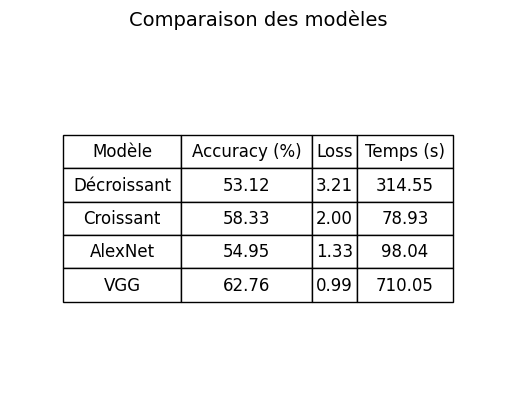

In [15]:
data = {
    "Modèle": ["Décroissant", "Croissant", "AlexNet", "VGG"],
    "Accuracy (%)": [
        f"{results_dcr[1]*100:.2f}",
        f"{results_cr[1]*100:.2f}",
        f"{results_alex[1]*100:.2f}",
        f"{results_vgg[1]*100:.2f}",
    ],
    "Loss": [
        f"{results_dcr[0]:.2f}",
        f"{results_cr[0]:.2f}",
        f"{results_alex[0]:.2f}",
        f"{results_vgg[0]:.2f}",
    ],
    "Temps (s)": [
        f"{results_dcr[2]:.2f}",
        f"{results_cr[2]:.2f}",
        f"{results_alex[2]:.2f}",
        f"{results_vgg[2]:.2f}",
    ]
}

df = pd.DataFrame(data)
fig, ax = plt.subplots()
ax.axis('off')
table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.auto_set_column_width(col=list(range(len(df.columns))))
table.scale(1, 2)

plt.title("Comparaison des modèles", fontsize=14)
plt.show()

 Les performances montrent que le modèle VGG est le plus performant en termes de précision 62,76 %.Le loss est de 0,99 il mesure l’écart entre les prédictions du modèle et les vraies valeurs. Celui ci indiquant une meilleure capacité d’apprentissage et de généralisation. Cependant, il présente un temps d’exécution très élevé 710,05 secondes , ce qui le rend coûteux en calcul.

Le modèle AlexNet offre un bon compromis avec une loss faible 1,33 et un temps modéré 98,04 secondes, mais une précision légèrement inférieure 54,95 %.

Les modèles croissant et décroissant sont moins performants globalement. Le modèle croissant reste toutefois plus efficace que le décroissant avec une meilleure précision 58,33 % contre 53,12 %, une loss plus faible et un temps d’exécution bien inférieur



---
MATRICE CONFUSION
---

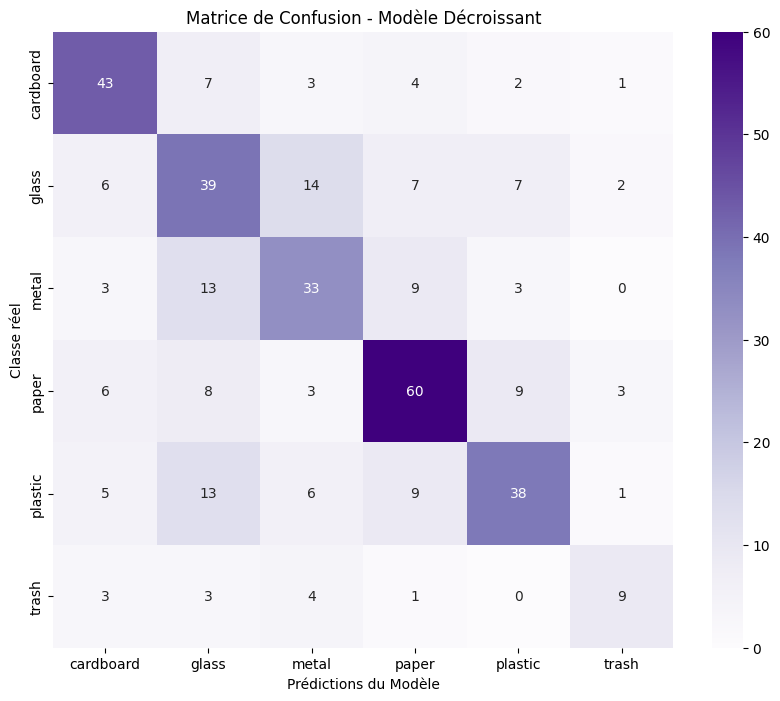

In [16]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model_dcr.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm_cr = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cr, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Modèle Décroissant')
plt.ylabel('Classe réel')
plt.xlabel('Prédictions du Modèle')
plt.show()

C'est le modèle le moin performant. La matrice montre une dispersion des erreurs sur presque toutes les catégories.
Il a beaucoup de mal à distinguer le métal et le plastique du verre.
Les prédictions sont moins franches, ce qui confirme les scores de Loss élevés vus précédemment.

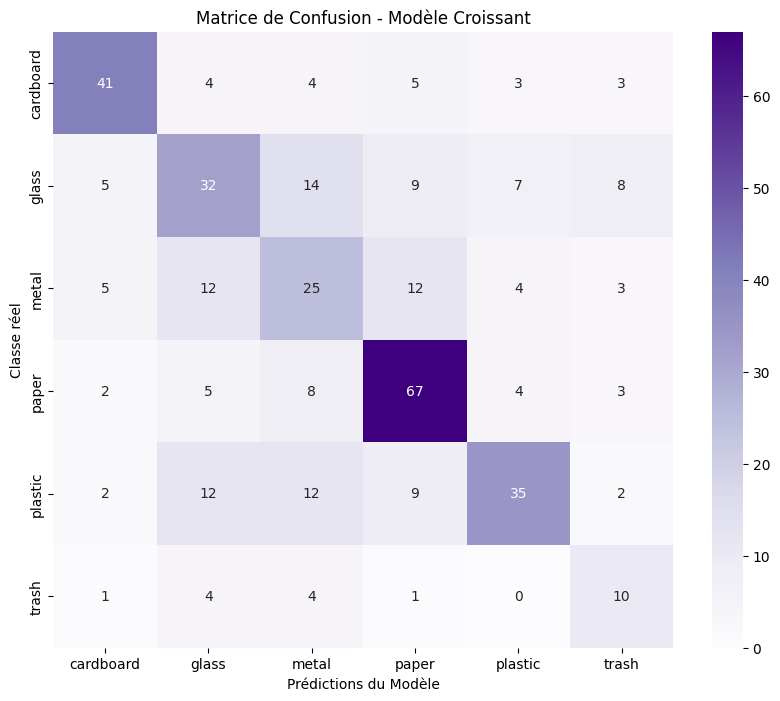

In [17]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model_cr.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm_cr = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cr, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Modèle Croissant')
plt.ylabel('Classe réel')
plt.xlabel('Prédictions du Modèle')
plt.show()

Bien que moins profond que les architectures standards.On remarque qu'il est très efficace pour le papier. Il peine davantage sur le métal, qu'il confond régulièrement avec le verre.


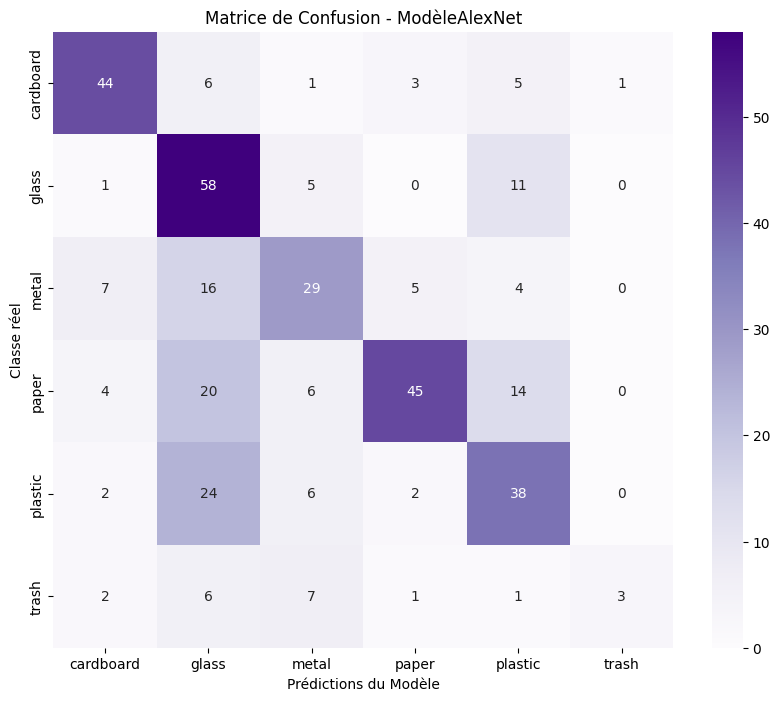

In [18]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model_alex.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm_cr = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cr, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - ModèleAlexNet')
plt.ylabel('Classe réel')
plt.xlabel('Prédictions du Modèle')
plt.show()

AlexNet obtient de bonnes performances globales, mais présente un biais. On constate une confusion importante, avec de nombreux échantillons classés à tort comme du verre, ce qui entraîne un taux élevé de faux positifs pour cette catégorie.

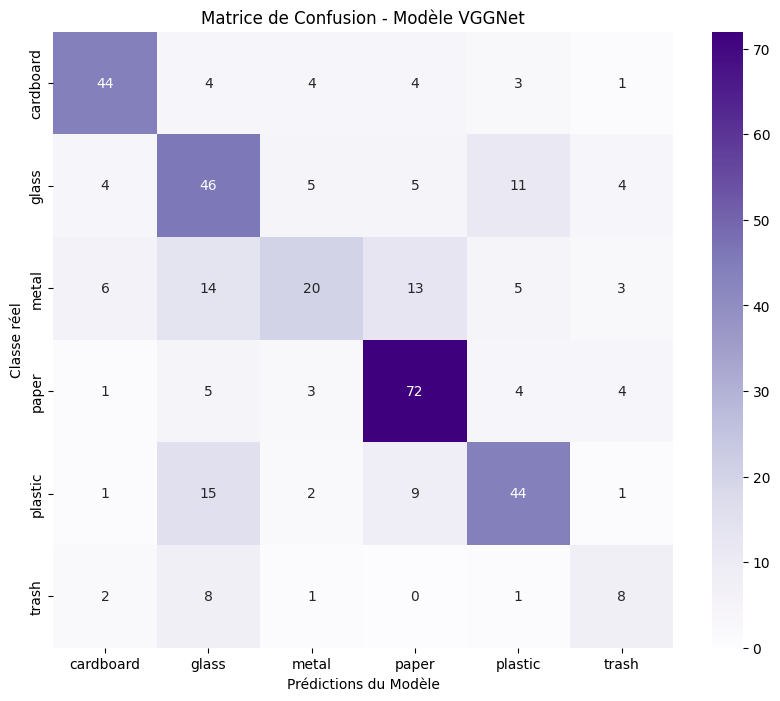

In [19]:
y_true = []
y_pred = []

for images, labels in val_data:
    preds = model_vgg.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm_cr = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_cr, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion - Modèle VGGNet')
plt.ylabel('Classe réel')
plt.xlabel('Prédictions du Modèle')
plt.show()


VGGNet s'impose comme le modèle le plus performant. Il présente la diagonale la plus marquée, ce qui signifie qu'il identifie correctement la majorité des classes. Il presente une bonne reconnaissance du papier 72 prédictions correctes sur 89. C'est le modèle qui disperse le moins ses erreurs, montrant une meilleure compréhension des caractéristiques visuelles des matériaux.

---
COnvergence

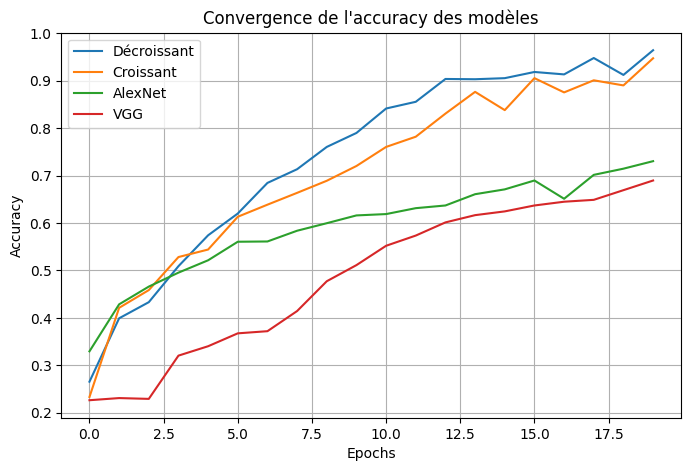

In [21]:
plt.figure(figsize=(8,5))

#Accuracy entraînement
plt.plot(history_dcr.history['accuracy'], label="Décroissant")
plt.plot(history_cr.history['accuracy'], label="Croissant")
plt.plot(history.history['accuracy'], label="AlexNet")
plt.plot(history_vgg.history['accuracy'], label="VGG")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Convergence de l'accuracy des modèles")

plt.legend()
plt.grid()

plt.show()

<div style="margin-left: 30px; font-size: 25px;">
  3.5. Discussion / Conclusion
</div>

Dans ce projet, nous avons appliqué plusieurs architectures de CNN pour la classification de nos données. Les résultats obtenus ont été décevants. Malgré nos efforts en parralle pour les améliorer, avons tenté diverses stratégies :

* l’augmentation des données afin d’élargir le jeu d’entraînement,
* un rééquilibrage des classes pour limiter le biais,
* l’augmentation du nombre de couches et du nombre d’époques pour permettre un apprentissage plus profond.

Cependant, ces ajustements n’ont pas conduit à des améliorations significatives, tout en entraînant un temps de calcul très élevé.

Cette limitation peut s’expliquer par plusieurs facteurs.
Qualité et complexité des données, certaines classes sont naturellement difficiles à distinguer, ce qui limite les performances des modèles.Egalement la taille de notre Dataset rentre en compte. Même avec de la data augmentation, le réseau peut rester sous-entraîné ou sur-apprendre certaines classes.
Limites de l’architecture choisie, certains CNN, comme AlexNet, ont un nombre de paramètres fixe qui peut ne pas suffire pour capturer toute la variabilité des données modernes.
Augmenter les couches et les époques améliore rarement les performances si le dataset ou la  du réseastructureu ne permet pas un apprentissage efficace.

En résumé,  les performances limitées semblent liées à une combinaison de la pauvreuté de nos données et des contraintes inhérentes à l’architecture et aux ressources disponibles. 
De plus une compréhension théorique plus approfondie nous permetraisde mieux exploiter comprendre Le Deep Learning, et plus particulièrement les CNN. Ces concepts mathématiques et structurels précis que nous avons hate de deveuloper dans la suite de notre cursus. 
Des approches alternatives, telles que l’utilisation de modèles plus récents ResNet, EfficientNet ,pourraient  également offrir de meilleurs résultats.

<a id="conclu"></a>
## 4. Conclusion